In [38]:
%load_ext autoreload
%autoreload 2

import sys
import pandas
sys.path.append("..")
#import pandas
import numpy as np
import matplotlib.pyplot as plt
import warnings
from numpy import random
from matplotlib import cm
#from matplotlib import norm
from matplotlib.colors import TwoSlopeNorm
warnings.filterwarnings('ignore')
import os


plotsdir  = '/Users/billiemeadowcroft/Dropbox/Collagen/RicardoProject/GithubCode/Data_and_Figures/Fig_NewAlignedRelaxation/Plots/'
datadir  = '/Users/billiemeadowcroft/Dropbox/Collagen/RicardoProject/GithubCode/Data_and_Figures/Fig_Relaxation/Data/'

import sys

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [39]:
def phiform(phi0,phi_inf,tau,t):
    if tau==0:
        phi = phi_inf
    else:
        phi = (phi0)*np.exp(-t/tau)+phi_inf
    return phi

def intersection(y,y0):
    diff = []
    for i in range(len(y)):
        #print(i)
        diff.append(float((y[i]-y0)*(y[i]-y0)))
    diff2 = sorted(diff)
    x = diff.index(diff2[0])
    return x,diff[x]

In [40]:
ClrsRiciChosen = ["#7883acff","#3e387bff","#73457aff","#a66181ff","#b25268ff","#d49995ff"]
ClrsRiciChosenHalf = ["#7883acff","#73457aff","#b25268ff","#d49995ff"]


## Plotting master protocol - ACTUAL

1.6356000000000002


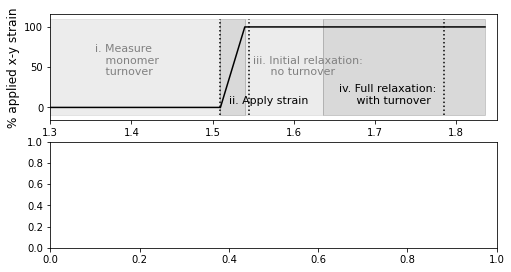

In [41]:

fig,ax = plt.subplots(2,1,figsize = (8,4.3))

text1 = 'Equilibrate'
text2 = 'i. Measure\n   monomer\n   turnover'
text3 = 'ii. Apply strain'
text4 = 'iii. Initial relaxation: \n     no turnover'
text5 = 'Add monomers'
text6 = 'iv. Full relaxation: \n     with turnover'

timeFactor = 10**6
t_Eq = (1509600*0.5)/timeFactor
t_MT = (1509600*0.5)/timeFactor +t_Eq
endOfEq = 1509600
t_strain = ((20000+10000)/timeFactor)+t_MT # ACTUAL ((20000+10000)/timeFactor)+t_MT

t_InitRel = 6000*16/timeFactor+t_strain
t_FulLRel = 200000/timeFactor+t_InitRel


times = [0,t_Eq,t_MT,t_strain,t_InitRel,t_FulLRel]
strains=[0,0,0,100,100,100]

ax[0].plot(times,strains,linestyle = '-',color = 'black')
ax[0].fill_between([0,t_Eq],[-10,-10],[110,110],alpha = 0.15,color = 'black')
ax[0].fill_between([t_Eq,t_MT],[-10,-10],[110,110],alpha = 0.15,color = 'grey')
ax[0].fill_between([t_MT,t_strain],[-10,-10],[110,110],alpha = 0.15,color = 'black')
ax[0].fill_between([t_strain,t_InitRel],[-10,-10],[110,110],alpha = 0.15,color = 'grey')
ax[0].fill_between([t_InitRel,t_FulLRel],[-10,-10],[110,110],alpha = 0.15,color = 'black')

ax[0].plot([t_MT,t_MT],[-10,110],linestyle = ':',color = 'black')
ax[0].plot([t_strain+0.005,t_strain+0.005],[-10,110],linestyle = ':',color = 'black')
ax[0].plot([t_InitRel+0.15,t_InitRel+0.15],[-10,110],linestyle = ':',color = 'black')
#ax.plot([2.3,2.3],[-10,110],linestyle = ':',color = 'black')
#ax.fill_between([t_addmons,t_FulLRel],[-10,-10],[110,110],alpha = 0.15,color = 'grey')

#ax.text(0.25,40,text1,fontsize = 11)
ax[0].text(t_Eq+.6,40,text2,color = 'grey',fontsize = 11)
ax[0].text(t_MT+0.01,5,text3,color = 'black',fontsize = 11)
ax[0].text(t_strain+0.01,40,text4,color = 'grey',fontsize = 11)
#ax.plot([1.61,1.72],[50,50],linestyle = '-',color = 'grey')
#ax.text(t_InitRel-0.3,12,text5,color = 'black',fontsize = 11)
ax[0].text(t_InitRel+0.02,5,text6,color = 'black',fontsize = 11)

ax[0].set_ylabel("% applied x-y strain",fontsize =12)
ax[0].set_xlabel('Time [$10^{6}\Delta t$]',fontsize = 12)
ax[0].set_xlim([-0.1,t_FulLRel+0.1])

ax[0].set_xlim([1.3,1.85])
#plotname = 'SimProtocol.png'
#fig.savefig(plotsdir+plotname)
print(t_InitRel)
#1639600

1.6356000000000002


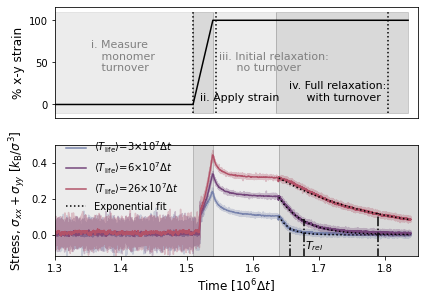

In [42]:
fig,ax = plt.subplots(2,1,figsize = (6,4.3))

text1 = 'Equilibrate'
text2 = 'i. Measure\n   monomer\n   turnover'
text3 = 'ii. Apply strain'
text4 = 'iii. Initial relaxation: \n     no turnover'
text5 = 'Add monomers'
text6 = 'iv. Full relaxation: \n     with turnover'

timeFactor = 10**6
t_Eq = (1509600*0.5)/timeFactor
t_MT = (1509600*0.5)/timeFactor +t_Eq
endOfEq = 1509600
t_strain = ((20000+10000)/timeFactor)+t_MT # ACTUAL ((20000+10000)/timeFactor)+t_MT

t_InitRel = 6000*16/timeFactor+t_strain
#t_addmons = 1000/timeFactor +t_InitRel
t_FulLRel = 200000/timeFactor+t_InitRel


times = [0,t_Eq,t_MT,t_strain,t_InitRel,t_FulLRel]
strains=[0,0,0,100,100,100]

ax[0].plot(times,strains,linestyle = '-',color = 'black')
ax[0].fill_between([0,t_Eq],[-10,-10],[110,110],alpha = 0.15,color = 'black')
ax[0].fill_between([t_Eq,t_MT],[-10,-10],[110,110],alpha = 0.15,color = 'grey')
ax[0].fill_between([t_MT,t_strain],[-10,-10],[110,110],alpha = 0.15,color = 'black')
ax[0].fill_between([t_strain,t_InitRel],[-10,-10],[110,110],alpha = 0.15,color = 'grey')
ax[0].fill_between([t_InitRel,t_FulLRel],[-10,-10],[110,110],alpha = 0.15,color = 'black')

ax[0].plot([t_MT,t_MT],[-10,110],linestyle = ':',color = 'black')
ax[0].plot([t_strain+0.005,t_strain+0.005],[-10,110],linestyle = ':',color = 'black')
ax[0].plot([t_InitRel+0.17,t_InitRel+0.17],[-10,110],linestyle = ':',color = 'black')
#ax.plot([2.3,2.3],[-10,110],linestyle = ':',color = 'black')
#ax.fill_between([t_addmons,t_FulLRel],[-10,-10],[110,110],alpha = 0.15,color = 'grey')

#ax.text(0.25,40,text1,fontsize = 11)
ax[0].text(t_Eq+.6,40,text2,color = 'grey',fontsize = 11)
ax[0].text(t_MT+0.01,5,text3,color = 'black',fontsize = 11)
ax[0].text(t_strain+0.01,40,text4,color = 'grey',fontsize = 11)
#ax.plot([1.61,1.72],[50,50],linestyle = '-',color = 'grey')
#ax.text(t_InitRel-0.3,12,text5,color = 'black',fontsize = 11)
ax[0].text(t_InitRel+0.02,5,text6,color = 'black',fontsize = 11)

ax[0].set_ylabel("% x-y strain",fontsize =12)
#ax[0].set_xlabel('Time [$10^{6}\Delta t$]',fontsize = 12)
ax[0].set_xlim([-0.1,t_FulLRel+0.1])

ax[0].set_xlim([1.3,1.85])
#plotname = 'SimProtocol.png'
#fig.savefig(plotsdir+plotname)
print(t_InitRel)
#1639600

xstretches = "51 76".split()
MPs = "0.1 0.03 0.01".split()
BPs = "0.03 0.01 0.003".split()
seeds1 = "1 2 3".split()
seeds2  = "1 3".split()
TmonAv = [3,6,26]

lenT0 = 75922
lenT1 = 3272
MP = "0.12 0.1 0.06 0.03 0.02 0.01".split() # ORIGINAL RANGE  0.12 0.1 0.06 0.03 0.02 0.01
BP = "0.04 0.03 0.02 0.01 0.007 0.003".split() # ORIGINAL RANGE 0.04 0.03 0.02 0.01 0.007 0.003
MPs = "0.1 0.03 0.01".split()
BPs = "0.03 0.01 0.003".split()
MP=MPs
BP=BPs
seeds1 = "1 2 3".split()
seeds2  = "1 3".split()
N=50

timeFactor = 10**6
t_Eq = (1509600*0.5)/timeFactor
t_MT = (1509600*0.5)/timeFactor +t_Eq
t_strain = ((20000+10000)/timeFactor)+t_MT
t_InitRel = 10000*10/timeFactor+t_strain
t_addmons = 1000/timeFactor +t_InitRel
t_FulLRel = 1000000/timeFactor+t_InitRel

times = [0,t_Eq,t_MT,t_strain,t_InitRel,t_FulLRel]
UP,LW=-0.15,0.65
ax[1].fill_between([0,t_Eq],[LW,LW],[UP,UP],alpha = 0.15,color = 'black')
ax[1].fill_between([t_MT,t_strain],[LW,LW],[UP,UP],alpha = 0.15,color = 'black')
ax[1].fill_between([t_Eq,t_MT],[LW,LW],[UP,UP],alpha = 0.15,color = 'grey')
ax[1].fill_between([t_strain,t_InitRel],[LW,LW],[UP,UP],alpha = 0.15,color = 'grey')
ax[1].fill_between([t_InitRel,t_FulLRel],[LW,LW],[UP,UP],alpha = 0.15,color = 'black')
xstretches = "51 76".split()
x=1
ax[1].set_xlabel('Time [$10^{6}\Delta t$]',fontsize = 12)
mrks = [":","-","--"]
alphs = [0.5,0.5,0.5]
Avtaus = []
Stdtaus = []

x=1
Vol1 = 51*51*12
Vol2 = (51+int(xstretches[x]))*(51+int(xstretches[x]))*12-Vol1
for p in range(len(MPs)):
    filename = 'stressdata_BP'+BP[p]+'.dat'
    
    StressData = pandas.read_csv(datadir+filename, header = 'infer',sep=' ')
    Time_ = StressData.Time
    stressTotAv_ = StressData.stressAv
    stressTotAv,Time = stressTotAv_.values,Time_.values
    rollingAvRelax = np.convolve(stressTotAv[lenT0+lenT1:], np.ones(N)/N, mode='valid')
    timePostStretch = np.add(Time[lenT0+lenT1:],-Time[lenT0+lenT1])[int(N/2):-int(N/2-1)]
    stressPostStretch = rollingAvRelax
    
    phi_inf = 0
    phi0 = stressPostStretch[10]
    phiTau = phi0/np.exp(1)
    tau = timePostStretch[intersection(stressPostStretch,phiTau)[0]]
    phiTheory = []
    for tt in range(len(timePostStretch)):
        t = timePostStretch[tt]
        phiTheory.append(phiform(phi0,phi_inf,tau,t))
    
    ax[1].plot(np.divide(Time[:int(t_InitRel*10**6/20)-2850],timeFactor),stressTotAv[:int(t_InitRel*10**6/20)-2850],color = ClrsRiciChosenHalf[p],alpha =0.3)
    ax[1].plot(np.divide(Time[int(t_InitRel*10**6/20)-1000:],timeFactor),stressTotAv[int(t_InitRel*10**6/20)-1000:],color = ClrsRiciChosenHalf[p],alpha =0.3)

    N=50
    rollingAv = np.convolve(stressTotAv, np.ones(N)/N, mode='valid')
    timeAv = Time[int(N/2):-int(N/2-1)]
    
    ax[1].plot(np.divide(timeAv,timeFactor),rollingAv,color = ClrsRiciChosenHalf[p],linestyle = '-',label = r'$\langle T_{\mathrm{life}}\rangle$='+str(TmonAv[p])+r'$\times10^7\Delta t$')
    
    if p==2:
        ax[1].plot(np.divide(np.add(timePostStretch,Time[lenT0+lenT1]),timeFactor),phiTheory,linestyle = ':',color = 'black',label = 'Exponential fit')
    else:
        ax[1].plot(np.divide(np.add(timePostStretch,Time[lenT0+lenT1]),timeFactor),phiTheory,linestyle = ':',color = 'black')
    tauAxis = np.add(np.divide(tau,timeFactor),t_InitRel)
    if p==0:
        ax[1].plot([tauAxis,tauAxis],[-0.13,0.04],linestyle = '-.',color = 'black')
    if p==1:
        ax[1].plot([tauAxis,tauAxis],[-0.13,0.09],linestyle = '-.',color = 'black')
    if p==2:
        ax[1].plot([tauAxis,tauAxis],[-0.13,0.12],linestyle = '-.',color = 'black')
ax[1].set_ylabel(r'Stress, $\sigma_{xx}+\sigma_{yy}~[k_{\mathrm{B}}/\sigma^{3}]$',fontsize = 12)
#ax.set_xlim([1.2,1.85])
text2 = r"$T_{rel}$"
ax[1].text(1.68,-0.08,text2,color = 'black',fontsize = 11)
ax[1].set_ylim([-0.12,0.5])
ax[1].set_xlim([1.3,1.85])
ax[0].set_xticks([])
ax[1].legend(frameon=False,loc = [0.02,0.37],fontsize = 10)
fig.tight_layout()
plotname = "Stress_relaxation_revision.pdf"
fig.savefig(plotsdir + plotname)